# WDB evolution with mass transfer

In [1]:
############################################################################
# Notebook to run the binary evolution after RLOF, considering mass transfer.
# No GW signal is studied here, only the orbital evolution.
############################################################################

Model the orbital evolution of mass-transfering WDB systems following the article Marsh, Nelemans, Steeghs '04 (astro-ph/0312577). The notebook uses some function of a general compact binary evolution from waveform_LO.py, hence at leading order only, and of the specific WDB from WD.py.
All computations in the notebook will assume the following units:
  
- masses in [Msol]
- distances in [m]
- times in [s]
  

The parameters to solve for are:

- $M_1$: mass of the accretor
- $M_2$: mass of the donor
- $a$: orbital separation

## Initial Settings

### Packages

In [1]:
import numpy as np
from scipy.optimize import root_scalar
from scipy.integrate import solve_ivp
from scipy.interpolate import interp1d
import math
import os
import pickle


import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.colors as colors
import scipy.constants as phconst

from Analysis_Scripts import constants as const
from Analysis_Scripts import WD
from Analysis_Scripts import waveform_LO
from Analysis_Scripts import plot_format as formatter

fs = 14
plt.rc('text', usetex=True)
plt.rc('font', family='serif')
plt.rcParams.update({'legend.fontsize': fs,
                     'axes.labelsize': fs,
                     'axes.titlesize': fs,
                     'xtick.labelsize': fs,
                     'ytick.labelsize': fs})

plt.rcParams["figure.figsize"] = (6,5)

# nicer ticks for logplots
import matplotlib.ticker

from matplotlib.ticker import LogFormatterSciNotation 
class CustomTicker(LogFormatterSciNotation):
  def __call__(self, x, pos = None): 
    if x not in [0.1, 1, 10]: 
      return LogFormatterSciNotation.__call__(self, x, pos = None) 
    else: 
      return "{x:g}".format(x = x) 

locmaj = matplotlib.ticker.LogLocator(base=10,numticks=100)
locmin = matplotlib.ticker.LogLocator(base=10.0,subs=(0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9), numticks=100)

locmaj2 = matplotlib.ticker.LogLocator(base=10,numticks=100)
locmin2 = matplotlib.ticker.LogLocator(base=10.0,subs=(0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9), numticks=100)

f_data = 'MT_Orbit_after_RLOF/'
if not os.path.exists(f_data):
  os.makedirs(f_data)


### Functions

Equations needed for the evolution of the mass transfer rate and orbital angular separation

In [2]:
def xL1(M1, M2):
    '''
    Returns the distance of the donor from the inner Lagrange point (L1)
    in units of the orbital separation by solving a fifth order polynomial 
    taken from https://en.wikipedia.org/wiki/Lagrange_point
    input:
        M1 - mass of the accretor in [Msol]
        M2 - mass of the donor in [Msol]
    output:
        dist of the donor from L1 in units of the orbital separation
    '''
    mm = waveform_LO.mu(M1, M2)
    fun = lambda x: x**5 + (mm-3.)*x**4 + (3.-2.*mm)*x**3 - mm*x**2 + 2.*mm*x - mm
    return root_scalar(fun, x0=0.001, x1=0.999).root

In [3]:
def a2(M1, M2):
    '''
    function parameterizing the distance of the donor to L1,
    Eq. (12) of astro-ph/0312577
    input:
        M1 - mass of the accretor in [Msol]
        M2 - mass of the donor in [Msol]
    output:
        a2
    '''
    mm = waveform_LO.mu(M1, M2)
    x = xL1(M1, M2)
    return mm/x**3 + (1.-mm)/(1.-x)**3

In [4]:
def fMT(M1, M2, a):
    '''
    function for mass transfer evolution,
    Eq. (10) of astro-ph/0312577
    input:
        M1 - mass of the accretor in [Msol]
        M2 - mass of the donor in [Msol]
        a - orbital separation in [m]
    output:
        f in [Msol/m^3/s]
    '''
    me = 4.581e-61 # electron mass in [Msol]
    mn = 8.42e-58 # nucleon mass in [Msol]
    mueprime = 2.
    temp_a2 = a2(M1, M2)
    return (
        8.*np.pi**3/9./1000**(3/2)
        * (5. * phconst.G * me *const.SolarMass**3 / phconst.h**2)**(3/2)  
        * (mueprime * mn)**(5/2)
        / waveform_LO.Porb(M1, M2, a)
        * (3. * waveform_LO.mu(M1, M2) * M2 / 5. /WD.RLOF2(M1/M2) / WD.WD_RadiusMass_Relation(M2)*1000)**(3/2)
        / np.sqrt(temp_a2 * (temp_a2 - 1.))
        )


In [5]:
def DM2(M1, M2, a):
    '''
    time derivative of the mass transfer rate,
    Eq. (9) of astro-ph/0312577
    Modified to return 0 if the donor is not overflowing its Roche Lobe
    input:
        M1 - mass of the accretor in [Msol]
        M2 - mass of the donor in [Msol]
        a - orbital separation in [m]
    output:
        time derivative of mass transfer rate in [Msol/s]
    '''
    temp_D = WD.Delta(M1, M2, a)
    return -fMT(M1, M2, a)*temp_D**3 * np.heaviside(temp_D, 0.)


In [6]:
def DJGWREL(M1, M2, a):
    '''
    relative loss of angular momentum to gravitational waves,
    Eq. (2) of astro - ph/0312577
    input:
        a - orbital separation in [m]
        M1 - mass of the accretor in [Msol]
        M2 - mass of the donor in [Msol]
    output:
        \dot{J}_GW/J_orb in [1/s]
    '''
    return (
        -32./5. 
        * (phconst.G*const.SolarMass)**3 / (phconst.c)**5
        * M1 * M2 * (M1 + M2) / a**4
        )


In [7]:
def rh(M1, M2):
    '''
    radius of the orbit around the accretor (in units of the orbital separation) 
    that has the same specific angular momentum as the transferred mass; 
    Eq. (13) of Verbunt & Rappaport 1988 with q -> 1/q
    input:
        M1 - mass of the accretor in [Msol]
        M2 - mass of the donor in [Msol]
    output:
        rh in units of the orbital separation
    '''
    l10q = np.log10(M2/M1)
    return (
        0.0883
        - 0.04858*l10q
        + 0.11489*l10q**2
        + 0.020475*l10q**3
        )

In [8]:
def Da(M1, M2, a, feedback):
    '''
    time evolution of orbital distance; 
    modified from Eq. (6) of astro-ph/0312577,
        - dropping the differential rotation term
        - adding the "feedback" parameter that should be set to 
            - 1 for the maximally unstable case 
              (all orbital momentum carried by the transferred mass 
              converted to spin of the accretor) 
            - 0 for the maximally stable case 
              (all orbital momentum carried by the transferred mass 
              fed back into the orbital angular momentum)
    input:
        M1 - mass of the accretor in [Msol]
        M2 - mass of the donor in [Msol]
        a - orbital separation in [m]
        feedback - should be 1 or 0
    output:
        time derivative of orbital separation [m/s]
    '''
    q = M2/M1
    return 2.*a*(
        DJGWREL(M1, M2, a)
        - DM2(M1, M2, a)/M2 * (
            1. - q - feedback*np.sqrt(
                (1. + q)*rh(M1, M2)
                )
            )
        )

## Method

### Integration of the mass transfer

This equation runs the evolution of the binary step by step, and stops the computation if an event for ending the life of the WDB happen:
- Mass transfer becomes critical: stop_DM2
- A mass of the teo WDs is too big/large for being a WD

In [9]:
def return_timeevolutionSTOP(IC_M1, IC_M2, feedbackFlag, tmax, IC_a=None, MTeff=1, stop_DM2=1e-2/const.year, max_step_choice=1e7, method_choice='RK45', High_Mass = 1.44, Low_Mass = 0.00057):
    '''
    returns a tuple (time, M1, M2, a) of solving the orbital evolution equations
    inputs:
        IC_M1 - mass of the donor in [Msol]
        IC_M2 - mass of the accretor in [Msol]
        feedbackFlag - set to 1 for maximally unstable / 0 for maximally stable case 
        tmax - time of evolution in [s]     
    optional inputs:
        IC_a - orbital separation at t=0 in [m]
               if no input is provide, this is set to the RLOF distance
        MTeff - parameter for mass transfer, DM1 = -MTeff*DM2, 
                if no input is provided, this is set to MTeff = 1,
                i.e. conservative mass transfer
        stop_DM2 - parameter for stopping the integration if DM2 > stop_DM2 in [Msol/s]
                   if no input is provided, this is set to stop_DM2 = 1e-2/const.year
        max_step_choice - maximum step size for the integrator in [s]
                          if no input is provided, this is set to max_step_choice = 1e7
        method_choice - choice of the integrator, see scipy.integrate.solve_ivp documentation
                        if no input is provided, this is set to method_choice = 'RK45'
        High_Mass - parameter for stopping the integration if M1 > High_Mass in [Msol]
                    if no input is provided, this is set to High_Mass = 1.44
        Low_Mass - parameter for stopping the integration if M2 < Low_Mass in [Msol]
                   if no input is provided, this is set to Low_Mass = 0.00057
    output:
        arrays of
            time in [s]
            M1(t) in [Msol]
            M2(t) in [Msol]
            a(t) in [m]
    '''
    # set IC_a to RLOF distance if no input provided       
    if IC_a is None:
        IC_a = WD.aRLOF(IC_M1, IC_M2)
    # set up the system of equations for the ode solver
    def ode_set(t, y):
        return np.array([
            -MTeff*DM2(y[0], y[1], y[2]),
            DM2(y[0], y[1], y[2]),
            Da(y[0], y[1], y[2], feedbackFlag)
            ])
    # set up the termination conditions
    # mass transfer becomes critical
    def hit_DMmax(t, y):
        return DM2(y[0], y[1], y[2]) + stop_DM2
    hit_DMmax.terminal = True
    # mass of the two WDs becomes too big/small
    def Bottom_Mass(t, y):
        return  y[1] - Low_Mass
    Bottom_Mass.terminal = True
    def Top_Mass(t, y):
        return y[0] - High_Mass
    Top_Mass.terminal = True
    
    Stop_Conditions = [hit_DMmax,Bottom_Mass,Top_Mass]
    # solve the equations
    sol = solve_ivp(
        ode_set,
        (0, tmax),
        np.array([IC_M1, IC_M2, IC_a]),
        method=method_choice,
        max_step=max_step_choice,
        events = Stop_Conditions
        )
    return sol.t, sol.y[0], sol.y[1], sol.y[2]    

### Find some timescales we are interested in

#### Finding the merger moment (when critical mass transfer stop_DM2 is reached)

In [10]:
def find_DMmax_time(IC_M1, IC_M2, feedbackFlag, tmax, IC_a=None, MTeff=1, stop_DM2=1e-2/const.year,  max_step_choice=1e7, method_choice='RK45', High_Mass = 1.44, Low_Mass = 0.00057):
    '''
    returns the time when the mass transfer exceeds a given rate
    Note that if the mass transfer rate does not exceed the threshold 
    before tmax, this function will return tmax!
    inputs:
        IC_M1 - mass of the donor in [Msol]
        IC_M2 - mass of the accretor in [Msol]
        feedbackFlag - set to 1 for maximally unstable / 0 for maximally stable case 
        tmax - time of evolution in [s]     
    optional inputs:
        IC_a - orbital separation at t=0 in [m]
               if no input is provide, this is set to the RLOF distance
        MTeff - parameter for mass transfer, DM1 = -MTeff*DM2, 
                if no input is provided, this is set to MTeff = 1,
                i.e. conservative mass transfer
        stop_DM2 - maximal mass transfer rate for which the output is computed in [Msol/s]
                   if no input is provided, this is set to 0.01 Msol/yr   
        max_step_choice - maximum step size for the integrator in [s]
                            if no input is provided, this is set to max_step_choice = 1e7
        method_choice - choice of the integrator, see scipy.integrate.solve_ivp documentation
                        if no input is provided, this is set to method_choice = 'RK45'
        High_Mass - parameter for stopping the integration if M1 > High_Mass in [Msol]
                    if no input is provided, this is set to High_Mass = 1.44
        Low_Mass - parameter for stopping the integration if M2 < Low_Mass in [Msol]
                   if no input is provided, this is set to Low_Mass = 0.00057
    output:
        time in [s] when the mass transfer rate equals stop_DM2. 
            if this condition is not met before tmax, this function returns tmax
    '''
     # set IC_a to RLOF distance if no input provided       
    if IC_a is None:
        IC_a = WD.aRLOF(IC_M1, IC_M2)
    # set up the system of equations for the ode solver
    def ode_set(t, y):
        return np.array([
            -MTeff*DM2(y[0], y[1], y[2]),
            DM2(y[0], y[1], y[2]),
            Da(y[0], y[1], y[2], feedbackFlag)
            ])
    # set up the termination conditions
    # mass transfer becomes critical
    def hit_DMmax(t, y):
        return DM2(y[0], y[1], y[2]) + stop_DM2
    hit_DMmax.terminal = True
    # mass of the two WDs becomes too big/small
    def Bottom_Mass(t, y):
        return  y[1] - Low_Mass
    Bottom_Mass.terminal = True
    def Top_Mass(t, y):
        return y[0] - High_Mass
    Top_Mass.terminal = True
    
    Stop_Conditions = [hit_DMmax,Bottom_Mass,Top_Mass]
    # solve the equations
    sol = solve_ivp(
        ode_set,
        (0, tmax),
        np.array([IC_M1, IC_M2, IC_a]),
        method=method_choice,
        max_step=max_step_choice,
        events = Stop_Conditions
        )
    return sol.t[-1],sol.y[0][-1],sol.y[1][-1],sol.y[2][-1]

#### Finding the time GW orbital evolution does not dominate anymore (GW dominatio determined by stop_dfGW_threshold)

In [11]:
def find_dfGW_time(IC_M1, IC_M2, feedbackFlag, tmax, stop_dfGW_threshold, IC_a=None, MTeff=1, max_step_choice=1e7, method_choice='RK45'):
    '''
    returns the time when the chirp, i.e. the time derivative of the GW signals
    starts to deviate from a GW-only system more than the input threshold (measured in 1-fdot_GW/fdot_full)
    Note that if this condition is never met, this function will return tmax!
    inputs:
        IC_M1 - mass of the donor in [Msol]
        IC_M2 - mass of the accretor in [Msol]
        feedbackFlag - set to 1 for maximally unstable / 0 for maximally stable case 
        tmax - time of evolution in [s]     
        stop_dFGW_threshold - relative deviation of the chirp for when to terminate the calculation
    optional inputs:
        IC_a - orbital separation at t=0 in [m]
               if no input is provide, this is set to the RLOF distance
        MTeff - parameter for mass transfer, DM1 = -MTeff*DM2, 
                if no input is provided, this is set to MTeff = 1,
                i.e. conservative mass transfer
        stop_DM2 - maximal mass transfer rate for which the output is computed in [Msol/s]
                   if no input is provided, this is set to 0.01 Msol/yr   
    output:
        time in [s] when the chirp deviates more than the threshold from a GW-only system
    '''
     # set IC_a to RLOF distance if no input provided       
    if IC_a is None:
        IC_a = WD.aRLOF(IC_M1, IC_M2)
    # set up the system of equations for the ode solver
    def ode_set(t, y):
        return np.array([
            -MTeff*DM2(y[0], y[1], y[2]),
            DM2(y[0], y[1], y[2]),
            Da(y[0], y[1], y[2], feedbackFlag)
            ])
    # set up the termination condition 
    # chirp deviates more than the threshold from a GW-only system
    def hit_dfGW_threshold(t, y):
        return np.abs(1. - 2*y[2]*DJGWREL(IC_M1, IC_M2, y[2])/Da(y[0], y[1], y[2], feedbackFlag)) - 3/2*stop_dfGW_threshold
    hit_dfGW_threshold.terminal = True
    # solve the equations
    sol = solve_ivp(
        ode_set,
        (0, tmax),
        np.array([IC_M1, IC_M2, IC_a]),
        method=method_choice,
        max_step=max_step_choice,
        events = hit_dfGW_threshold
        )
    return sol.t[-1],sol.y[0][-1],sol.y[1][-1],sol.y[2][-1]


### Finding a phase shift of Xpi

#### Phase of a GW dominated binary evolution

In [12]:
def GWPhase(Mc, Deltat, tau0, Theta0):
   '''
   Returns the phase of the GW signal in radians, using Eq. 4.193 of Maggiore 
   inputs:
      Mc -- detector frame chirp mass [Msol]
      Deltat (t-t0) -- time from the reference time [s] 
      t0 -- time of reference to coalescence [s] 
      Theta0 -- GW phase at time of reference
   output:
      GW phase at time t in [rad]
   '''
   return -2.*(5.*(phconst.G*const.SolarMass)*Mc/(phconst.c)**3)**(-5./8.)*((-Deltat+tau0)**(5./8.) - (tau0)**(5./8.))+Theta0

#### Given a X pi phase, find the time at which this phase is reached

In [13]:
def PhaseFinder(PhaseDifference, m1, m2, feedbackFlag, tmax, t0=0, stop_DM2=1e-2/const.year, phase_MTeff=1, phase_method_choice='RK45', integral_steps=1000):
    sol_ev_t, sol_ev_m1, sol_ev_m2, sol_ev_a = return_timeevolutionSTOP(m1, m2, feedbackFlag, tmax, MTeff=phase_MTeff, method_choice=phase_method_choice)
    '''
    This function uses return_timeevolutionSTOP to get the orbital evolution after RLOF,
    Knowing the evolution computes the phase of the system at every step and checks when a given phase difference is reached
    inputs:
        PhaseDifference -- phase difference in units of pi
        m1 -- mass of the donor in [Msol]
        m2 -- mass of the accretor in [Msol]
        feedbackFlag -- set to 1 for maximally unstable / 0 for maximally stable case 
        tmax -- time of evolution in [s]     
    optional inputs:
        t0 -- time of reference to coalescence [s], default is 0
        stop_DM2 -- parameter for stopping the integration if DM2 > stop_DM2 in [Msol/s], default is stop_DM2 = 1e-2/const.year
        phase_MTeff -- parameter for mass transfer, DM1 = -MTeff*DM2, default is MTeff = 1,
                i.e. conservative mass transfer
        phase_method_choice -- choice of the integrator, see scipy.integrate.solve_ivp documentation, default is method_choice = 'RK45'
        integral_steps -- number of steps for the integral, default is integral_steps = 1000
    outputs:
        time of merger in [s]
        frequency at merger in [Hz]
        time after t0 at which the phase difference is reached in [s]
        frequency at which the phase difference is reached in [Hz]
    If the phase difference is not reached before merger, the last two outputs are NaN  
    '''
    #frequency evolution
    sol_ev_f=waveform_LO.forb(sol_ev_m1,sol_ev_m2,sol_ev_a)*2

    # Create an interpolation function of the frequency evolution
    MTf = interp1d(sol_ev_t, 2*np.pi*sol_ev_f, kind='cubic')

    # compute the parameters for the phase evolution: chirp mass and time to coalescence at t0
    Mc_phase=waveform_LO.Mc(m1, m2)
    fRLOF_phase=waveform_LO.forb(m1,m2,WD.aRLOF(m1,m2))*2
    tau0_phase=waveform_LO.tau_fGW(Mc_phase, fRLOF_phase)

    # check if t0 is before merger (in the point mass case)
    if t0>tau0_phase or t0>sol_ev_t[-1]:
        print("Time of reference is after the merger")
        return sol_ev_t[-1],sol_ev_f[-1],np.nan

    # compute the phase difference between the mass transfer evolution (MTf) and the GW only evolution (GWPhase)
    def PhaseDifference_temp(t):
        integral_time=np.linspace(t0,t+t0,integral_steps)
        MTf_inter= np.trapz(MTf(integral_time), integral_time)
        return abs(MTf_inter-GWPhase(Mc_phase, t, tau0_phase-t0, 0))-PhaseDifference*np.pi
    
    # find the time when the phase difference is reached, if it is not reached return NaN (the binary merged before)
    try:
        solution_phase=root_scalar(PhaseDifference_temp, bracket=[1, sol_ev_t[-1]-t0], maxiter=1000).root
        sol_return=solution_phase # Time at which the phase difference is reached

        sol_return_index=np.argmin(abs(sol_ev_t-t0-solution_phase))
        sol_return_f=waveform_LO.forb(sol_ev_m1[sol_return_index],sol_ev_m2[sol_return_index],sol_ev_a[sol_return_index])*2 # frequency at which the phase difference is reached
        
    except:
        sol_return=np.nan
        sol_return_f=np.nan

    return sol_ev_t[-1],sol_ev_f[-1],t0+sol_return,sol_return_f

## Example computations

The stable case is studied (see paper)

### Compute frequency and time at merger

#### Inputs (can be modified)

In [14]:
# Output for merger time
minmass=0.4 # minimal WD mass
maxmass=1.4 # maximal WD mass
rangelength=30 # number of bins

# Mass transfer parameters 
plot_feedbackFlag = 0 # 0 for maximally stable, 1 for maximally unstable
plot_tmax = 1e9 # maximal time of evolution in [s]
plot_stop_dfGW_threshold = 1e-2 # threshold for stopping the integration when the chirp deviates more than this from a GW-only system
plot_method_choice= "BDF" # choice of the integrator, see scipy.integrate.solve_ivp documentation
plot_MTeff= 1 # parameter for mass transfer, DM1 = -MTeff*DM2, default is MTeff = 1

#### Run for a $M_1$-$M_2$ grid

In [15]:
#run over a range of variables

m1_range=np.linspace(minmass,maxmass,rangelength)
m2_range=np.linspace(minmass,maxmass,rangelength)

X, Y = np.meshgrid(m1_range,m2_range)

if not os.path.exists(f_data + f'Timespan_Nbin{rangelength}_Stable.pkl'):

    mergertime = np.full((rangelength, rangelength), np.nan)
    mergerfrequency= np.full((rangelength, rangelength), np.nan)

    status=0
    for i in range(rangelength):
        j=0
        while i > j:      
            plot_M1 = m1_range[i]        # initial mass of the accretor in [Msol]
            plot_M2 = m2_range[j]        # initial mass of the donor in [Msol]


            sol_t,sol_M1,sol_M2,sol_a=find_DMmax_time(plot_M1, plot_M2, plot_feedbackFlag, plot_tmax, MTeff=plot_MTeff, method_choice=plot_method_choice)
            mergertime[i,j]=sol_t
            mergerfrequency[j,i]=waveform_LO.forb(sol_M1, sol_M2, sol_a)

            j+=1

        if (i+1)/rangelength>=status/100:    
            print(status,"%")
            status+=int(100/min(10**math.floor(np.log10(rangelength)),100))


    with open(os.path.join(f_data + f'Timespan_Nbin{rangelength}_Stable.pkl'), "wb") as f:
        pickle.dump((mergertime,mergerfrequency,), f)  # Save as a tuple
    print("Data saved")

else:
    # Load results
    with open(os.path.join(f_data + f'Timespan_Nbin{rangelength}_Stable.pkl'), "rb") as f:
        mergertime,mergerfrequency = pickle.load(f)  # Unpack directly
    print("Data loaded")


Data loaded


The results are computed unless already present, in that case they are recovered from storage. Numerical errors might arise due to the root solve and specific combination of parameters.

#### Initialize the inputs for the plot

In [16]:
#Make the two plot consistents

mergertime_plot=(np.where(mergertime < plot_tmax, mergertime, np.nan))/const.year

mergerfrequency_plot=(np.where(mergertime.T < plot_tmax, mergerfrequency, np.nan))

lowest_10=math.floor(math.log10(np.nanmin(mergertime_plot)))
highest_10=int(np.log10(plot_tmax/const.year))
levelstime=np.logspace(lowest_10,highest_10,(highest_10-lowest_10)*2+1)

lowest_10_freq=np.nanmin(mergerfrequency_plot)
highest_10_freq=np.nanmax(mergerfrequency_plot)
levelsfrequency=np.geomspace(lowest_10_freq,highest_10_freq,9)         


qunstableb=np.copy(Y/X-WD.qunstabilitylimit(X,Y))
qstableb=np.copy(Y/X-WD.qstabilitylimit(X,Y))
distanceb=WD.WD_RadiusMass_Relation(Y)/WD.RLOF2(X/Y)
Rminb=(0.04948-0.03815*np.log10(Y/X)+0.04752*np.log10(Y/X)**2-0.006973*np.log10(Y/X)**3)*distanceb
directdiskb=np.copy(Rminb-WD.WD_RadiusMass_Relation(X))

qunstablel=np.copy(X/Y-WD.qunstabilitylimit(Y,X))
qstablel=np.copy(X/Y-WD.qstabilitylimit(Y,X))
distancel=WD.WD_RadiusMass_Relation(X)/WD.RLOF2(Y/X)
Rminl=(0.04948-0.03815*np.log10(X/Y)+0.04752*np.log10(X/Y)**2-0.006973*np.log10(X/Y)**3)*distancel
directdiskl=np.copy(Rminl-WD.WD_RadiusMass_Relation(Y))

RLOF_freq=waveform_LO.forb(X,Y,WD.WD_RadiusMass_Relation(Y)/WD.RLOF2(X/Y))

#compute the orbital frequency, if the binary would have evolved with GW only
ChirpMass=waveform_LO.Mc(X,Y)
Initial_Tau=waveform_LO.tau_fGW(ChirpMass, waveform_LO.forb(X,Y,WD.WD_RadiusMass_Relation(Y)/WD.RLOF2(X/Y))*2)
GWonly_freq=waveform_LO.fGW(ChirpMass, Initial_Tau+mergertime.T)/2

# Define some nice ticks for the plots
frequency_ticks = levelsfrequency
frequency_ticks_labels = [formatter.fmt3(x,1) for x in frequency_ticks]

mergertime_ticks = levelstime
mergertime_ticks_labels = [formatter.scientific_formatter(x,1) for x in mergertime_ticks]




#### Plot

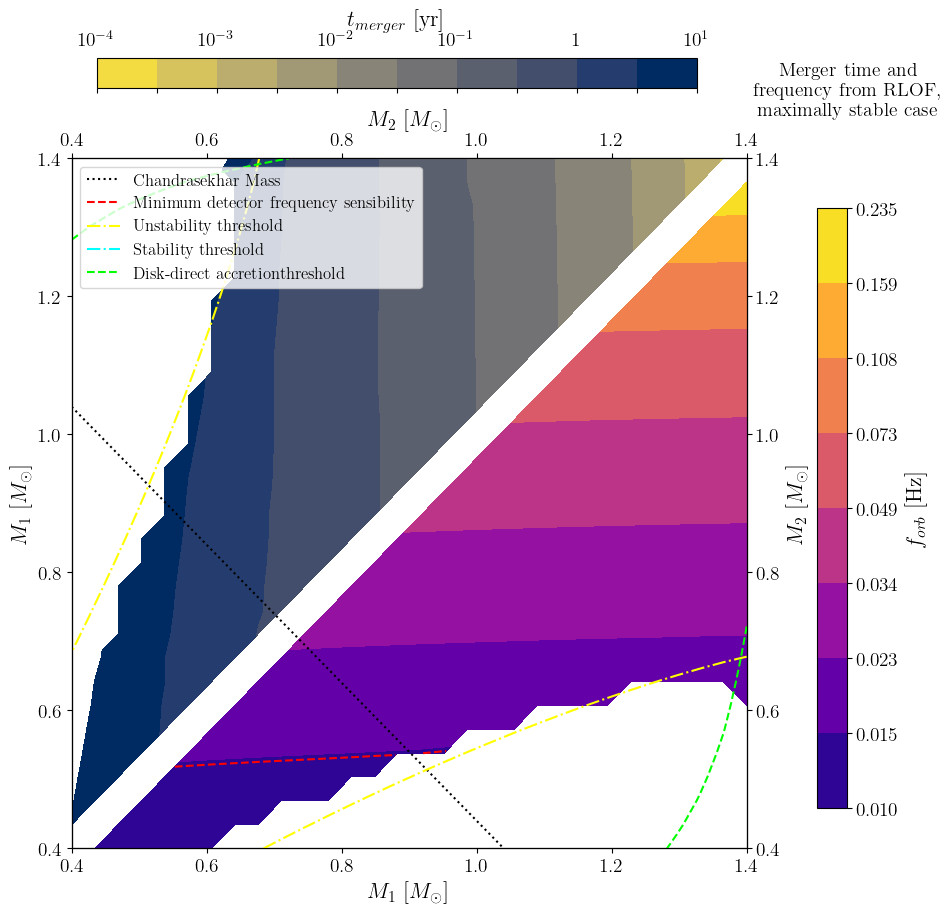

In [17]:
title="Merger time and\nfrequency from RLOF"
if plot_feedbackFlag==1:
    title+=", \n maximally unstable case"
elif plot_feedbackFlag==0:
    title+=", \n maximally stable case"

fig = plt.figure(figsize=(10, 10))
ax1 = fig.add_subplot(111)
fig.subplots_adjust(right=0.8, top=0.8)
plt.title(title, fontsize=14,x=1.15,y=1.05)
ax2 = ax1.twinx()


#Plot frequency in the bottom right part of the plot
fContour = ax2.contourf(X, Y, mergerfrequency_plot, levels=levelsfrequency,norm=colors.LogNorm(),cmap="plasma")
#Add colorbar, manually positioned
fcax = fig.add_axes([.87, 0.15, 0.03, 0.6])
fbar = plt.colorbar(fContour,label=r"$f_{orb}$ [Hz]", orientation='vertical', cax=fcax)
fbar.ax.yaxis.label.set_size(16) 
fbar.set_ticks(frequency_ticks)
fbar.set_ticklabels(frequency_ticks_labels) 

ax3 = ax1.twiny()
#Plot time
tContour=ax3.contourf(X,Y,mergertime_plot, levels=levelstime, norm=colors.LogNorm(),cmap=plt.cm.cividis.reversed())
tcax = fig.add_axes([0.15, .87, 0.6, 0.03])
tbar = plt.colorbar(tContour,label=r"$t_{merger}$ [yr]", orientation='horizontal', cax=tcax)
tbar.ax.tick_params(labeltop=True,labelbottom=False)
tbar.ax.xaxis.set_label_position('top')
tbar.ax.xaxis.label.set_size(16) 
tbar.set_ticks(mergertime_ticks)
tbar.set_ticklabels(mergertime_ticks_labels)


ax1.set_ylabel(r"$M_{1}$ [$M_\odot$]", fontsize=16)
ax3.set_xlabel(r"$M_{2}$ [$M_\odot$]", fontsize=16)
ax1.set_xlabel(r"$M_{1}$ [$M_\odot$]", fontsize=16)
ax2.set_ylabel(r"$M_{2}$ [$M_\odot$]", fontsize=16)


#Plot chandrasekar mass and detector limit contour
ax3.contour(X,Y,X+Y, levels=[1.44],colors="black",linestyles="dotted")
proxy_CHMass = plt.Line2D([0], [0], color='black', linestyle='dotted')
ax2.contour(X,Y,mergerfrequency_plot, levels=[0.0301995/2],colors="red",linestyles="dashed",linewidths=1.5)
proxy_Detector = plt.Line2D([0], [0], color='red', linestyle='dashed',linewidth=1.5)

ax3.contour(X,Y,qunstableb,levels=[0],colors="yellow",linestyles="dashdot")
ax3.contour(X,Y,qunstablel,levels=[0],colors="yellow",linestyles="dashdot")
proxy_qunstable = plt.Line2D([0], [0], color='yellow', linestyle='dashdot')
ax3.contour(X,Y,qstableb,levels=[0],colors='aqua',linestyles="dashdot")
ax3.contour(X,Y,qstablel,levels=[0],colors='aqua',linestyles="dashdot")
proxy_qstable = plt.Line2D([0], [0], color='aqua', linestyle='dashdot')
ax3.contour(X,Y,directdiskb,levels=[0],colors='lime',linestyles='dashed')
ax3.contour(X,Y,directdiskl,levels=[0],colors='lime',linestyles='dashed')
proxy_directdisk = plt.Line2D([0], [0], color='lime',linestyle='dashed')

ax3.legend([proxy_CHMass, proxy_Detector,proxy_qunstable,proxy_qstable,proxy_directdisk],
           ["Chandrasekhar Mass", 
            "Minimum detector frequency sensibility",
            "Unstability threshold",
            "Stability threshold",
            "Disk-direct accretionthreshold"],
            fontsize=12,loc="upper left")

plt.show() 

### Example for timescales with 1 pi difference, stable case

#### Inputs (can be modified)

In [18]:
# Output for merger time
minmass=0.4 # minimal WD mass
maxmass=1.4 # maximal WD mass
rangelength=30 # number of bins

# Mass transfer parameters 
plot_PhaseDifference = 1 # phase difference in units of pi
plot_feedbackFlag = 0 # 0 for maximally stable, 1 for maximally unstable
plot_tmax = 1e9 # maximal time of evolution in [s]
plot_stop_dfGW_threshold = 1e-2 # threshold for stopping the integration when the chirp deviates more than this from a GW-only system
plot_method_choice= "BDF" # choice of the integrator, see scipy.integrate.solve_ivp documentation
plot_MTeff= 1 # parameter for mass transfer, DM1 = -MTeff*DM2, default is MTeff = 1

#### Run for a $M_1$-$M_2$ grid

In [19]:

#run over a range of variables

m1_range=np.linspace(minmass,maxmass,rangelength)
m2_range=np.linspace(minmass,maxmass,rangelength)

X, Y = np.meshgrid(m1_range,m2_range)

if not os.path.exists(f_data + f'Phase{plot_PhaseDifference}_Nbin{rangelength}_Stable.pkl'):

    PhaseTime = np.full((rangelength, rangelength), np.nan)
    PhaseFrequency = np.full((rangelength, rangelength), np.nan)
    mergertime_phase = np.full((rangelength, rangelength), np.nan)
    mergerGWfrequency_phase = np.full((rangelength, rangelength), np.nan)

    status=0
    for i in range(rangelength):
        j=0
        while i > j:      
            plot_M1 = m1_range[i]        # initial mass of the accretor in [Msol]
            plot_M2 = m2_range[j]        # initial mass of the donor in [Msol]
            mergertime_phase[j,i],mergerGWfrequency_phase[j,i],PhaseTime[j,i],PhaseFrequency[j,i] = PhaseFinder(plot_PhaseDifference, plot_M1, plot_M2, plot_feedbackFlag, plot_tmax, phase_MTeff=plot_MTeff, phase_method_choice=plot_method_choice)

            j+=1

        if (i+1)/rangelength>=status/100:    
            print(status,"%")
            status+=int(100/min(10**math.floor(np.log10(rangelength)),100))


    with open(os.path.join(f_data, f'Phase{plot_PhaseDifference}_Nbin{rangelength}_Stable.pkl'), "wb") as f:
        pickle.dump((PhaseTime,PhaseFrequency,mergertime_phase,mergerGWfrequency_phase), f)  # Save as a tuple
    print("Data saved")

else:
    # Load results
    with open(os.path.join(f_data, f'Phase{plot_PhaseDifference}_Nbin{rangelength}_Stable.pkl'), "rb") as f:
        PhaseTime,PhaseFrequency,mergertime_phase,mergerGWfrequency_phase = pickle.load(f)  # Unpack directly
    print("Data loaded")

Data loaded


The results are computed unless already present, in that case they are recovered from storage. Numerical errors might arise due to the root solve and specific combination of parameters.

#### Initialize the inputs for the plot

In [20]:

mergertime_phase_plot=(np.where(mergertime_phase < plot_tmax, mergertime_phase, np.nan))
PhaseTime_before_Merger = mergertime_phase_plot - PhaseTime

mergerfrequency_phase_plot=(np.where(mergertime_phase < plot_tmax/2, mergerGWfrequency_phase, np.nan)) #/2 only needed for nice plots


qunstableb=np.copy(Y/X-WD.qunstabilitylimit(X,Y))
qstableb=np.copy(Y/X-WD.qstabilitylimit(X,Y))
distanceb=WD.WD_RadiusMass_Relation(Y)/WD.RLOF2(X/Y)
Rminb=(0.04948-0.03815*np.log10(Y/X)+0.04752*np.log10(Y/X)**2-0.006973*np.log10(Y/X)**3)*distanceb
directdiskb=np.copy(Rminb-WD.WD_RadiusMass_Relation(X))

qunstablel=np.copy(X/Y-WD.qunstabilitylimit(Y,X))
qstablel=np.copy(X/Y-WD.qstabilitylimit(Y,X))
distancel=WD.WD_RadiusMass_Relation(X)/WD.RLOF2(Y/X)
Rminl=(0.04948-0.03815*np.log10(X/Y)+0.04752*np.log10(X/Y)**2-0.006973*np.log10(X/Y)**3)*distancel
directdiskl=np.copy(Rminl-WD.WD_RadiusMass_Relation(Y))

RLOF_freq=(np.where(X > Y, WD.WD_RLOFCutoffFrequency(X,Y), np.nan))

#compute the orbital frequency, if the binary would have evolved with GW only
ChirpMass=waveform_LO.Mc(X,Y)
Initial_Tau=waveform_LO.tau_fGW(ChirpMass, waveform_LO.Frequency_Distance(WD.WD_RadiusMass_Relation(Y)/1000/WD.RLOF2(X/Y),X,Y))
GWonly_freq=waveform_LO.fGW(ChirpMass, Initial_Tau+mergertime_phase.T)/2



# Define some nice ticks for the plot
plot_tmin = 1e-3 # approximately 3 hours
plot_tmax = 1e2 # approximately 10 years

PhaseTime_plot = PhaseTime/const.year
PhaseTime_before_Merger_plot = PhaseTime_before_Merger/const.year


plot_tmin_phase = plot_tmin*10
plot_tmax_phase = plot_tmax/10

min_plot_phase=min(plot_tmin_phase/10**.5,np.nanmin(PhaseTime_plot))
max_plot_phase=max(plot_tmax_phase*10**.5,np.nanmax(PhaseTime_plot))

ticks_phase = np.geomspace(plot_tmin_phase,plot_tmax_phase,round(np.log10(plot_tmax_phase/plot_tmin_phase))*2+1)
# tick_labels=["%.1e"% x for x in ticks]
tick_labels_phase=[formatter.scientific_formatter(x,1) for x in ticks_phase]

ticks_phase = np.insert(ticks_phase, 0, min_plot_phase)
tick_labels_phase.insert(0, '')
tick_labels_phase[1] = f'$<${formatter.scientific_formatter(plot_tmin_phase,1)}'
ticks_phase = np.append(ticks_phase, max_plot_phase)
tick_labels_phase.append(f'')
tick_labels_phase[-2] = f'$>${formatter.scientific_formatter(plot_tmax_phase,1)}'

norm_phase = colors.BoundaryNorm(boundaries=ticks_phase, ncolors=256)

plot_tmin_merger = plot_tmin
plot_tmax_merger = plot_tmax

min_plot_merger=min(plot_tmin_merger/10,np.nanmin(PhaseTime_before_Merger_plot))
max_plot_merger=max(plot_tmax_merger*10,np.nanmax(PhaseTime_before_Merger_plot))

ticks_merger = np.geomspace(plot_tmin_merger,plot_tmax_merger,round(np.log10(plot_tmax_merger/plot_tmin_merger))*1+1)
tick_labels_merger=[formatter.scientific_formatter(x,1) for x in ticks_merger]

ticks_merger = np.insert(ticks_merger, 0, min_plot_merger)
tick_labels_merger.insert(0, '')
tick_labels_merger[1] = f'$<${formatter.scientific_formatter(plot_tmin_merger,1)}'
ticks_merger = np.append(ticks_merger, max_plot_merger)
tick_labels_merger.append('')
tick_labels_merger[-2] = f'$>${formatter.scientific_formatter(plot_tmax_merger,1)}'

norm_merger = colors.BoundaryNorm(boundaries=ticks_merger, ncolors=256)

#### Plot

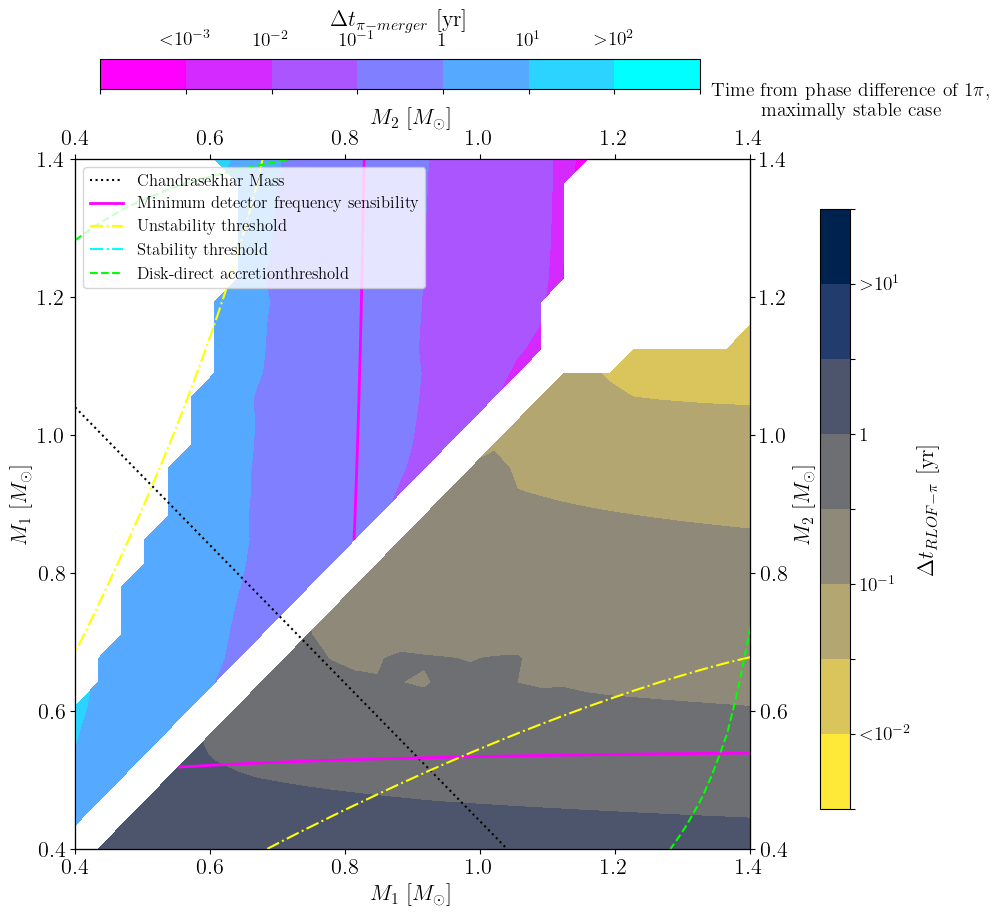

In [21]:
title=f"Time from phase difference of {plot_PhaseDifference}"+r"$\pi$"
if plot_feedbackFlag==1:
    title+=",\n maximally unstable case"
elif plot_feedbackFlag==0:
    title+=",\n maximally stable case"


fig = plt.figure(figsize=(10, 10))
ax1 = fig.add_subplot(111)
fig.subplots_adjust(right=0.8, top=0.8)
plt.title(title, fontsize=14,x=1.15,y=1.05)
ax2 = ax1.twinx()

#Plot frequency in the bottom right part of the plot
fcontour = ax2.contourf(X, Y, PhaseTime_plot, levels=ticks_phase, norm=norm_phase, cmap=plt.cm.cividis.reversed())
#Add colorbar, manually positioned
fcax = fig.add_axes([.87, 0.15, 0.03, 0.6])
fbar = plt.colorbar(fcontour,label=r"$\Delta t_{RLOF-\pi}$ [yr]", orientation='vertical', cax=fcax)
fbar.ax.yaxis.label.set_size(16) 
fbar.set_ticks(ticks_phase)
fbar.set_ticklabels(tick_labels_phase) 


ax3 = ax1.twiny()
#Plot frequency in the bottom right part of the plot
tcontour = ax3.contourf(X, Y, PhaseTime_before_Merger_plot.T, levels=ticks_merger, norm=norm_merger,cmap=plt.cm.cool.reversed())
#Add colorbar, manually positioned
tcax = fig.add_axes([0.15, .87, 0.6, 0.03])
tbar = plt.colorbar(tcontour,label=r"$\Delta t_{\pi-merger}$ [yr]", orientation='horizontal', cax=tcax)
tbar.ax.tick_params(labeltop=True,labelbottom=False)
tbar.ax.xaxis.set_label_position('top')
tbar.ax.xaxis.label.set_size(16) 
tbar.set_ticks(ticks_merger)
tbar.set_ticklabels(tick_labels_merger) 



ax1.set_ylabel(r"$M_{1}$ [$M_\odot$]", fontsize=16)
ax3.set_xlabel(r"$M_{2}$ [$M_\odot$]", fontsize=16)
ax1.set_xlabel(r"$M_{1}$ [$M_\odot$]", fontsize=16)
ax2.set_ylabel(r"$M_{2}$ [$M_\odot$]", fontsize=16)

ax1.xaxis.set_tick_params(labelsize=16)  # X-axis ticks
ax1.yaxis.set_tick_params(labelsize=16)  # Y-axis ticks
ax3.xaxis.set_tick_params(labelsize=16)  # X-axis ticks
ax2.yaxis.set_tick_params(labelsize=16)  # Y-axis ticks

#Plot chandrasekar mass and detector limit contour
ax3.contour(X,Y,X+Y, levels=[1.44],colors="black",linestyles="dotted")
proxy_CHMass = plt.Line2D([0], [0], color='black', linestyle='dotted')
ax3.contour(X,Y,PhaseFrequency, levels=[0.0301995],colors='magenta', linestyles='solid',linewidths=2)
ax3.contour(X,Y,mergerfrequency_plot.T, levels=[0.0301995],colors='magenta', linestyles='solid',linewidths=2)
proxy_Detector = plt.Line2D([0], [0], color='magenta', linestyle='solid',linewidth=2)


ax3.contour(X,Y,qunstableb,levels=[0],colors="yellow",linestyles="dashdot")
ax3.contour(X,Y,qunstablel,levels=[0],colors="yellow",linestyles="dashdot")
proxy_qunstable = plt.Line2D([0], [0], color='yellow', linestyle='dashdot')
ax3.contour(X,Y,qstableb,levels=[0],colors='aqua',linestyles="dashdot")
ax3.contour(X,Y,qstablel,levels=[0],colors='aqua',linestyles="dashdot")
proxy_qstable = plt.Line2D([0], [0], color='aqua', linestyle='dashdot')
ax3.contour(X,Y,directdiskb,levels=[0],colors='lime',linestyles='dashed')
ax3.contour(X,Y,directdiskl,levels=[0],colors='lime',linestyles='dashed')
proxy_directdisk = plt.Line2D([0], [0], color='lime',linestyle='dashed')

ax3.legend([proxy_CHMass, proxy_Detector,proxy_qunstable,proxy_qstable,proxy_directdisk],
           ["Chandrasekhar Mass", 
            "Minimum detector frequency sensibility",
            "Unstability threshold",
            "Stability threshold",
            "Disk-direct accretionthreshold"],
            fontsize=12,loc="upper left")

plt.show() 

End